# A Tale of Two States
## How Washington D.C. and West Virginia Reveal the Great Divide in American Health (1999 to 2017)

Every year, the United States shares data on how and where people die. On the surface, the national average shows steady progress. But when we look closer at individual states and specific causes of death, we see a different story.

This notebook explores the changing paths of American health. We will see how different regions went in completely opposite directions over eighteen years. Some parts of the country made great progress, while others fell behind. Let's start with the national picture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style settings for publication-quality visual identity
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.edgecolor'] = '#ccd1d1'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#f2f4f4'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
plt.rcParams['xtick.color'] = '#7f8c8d'
plt.rcParams['ytick.color'] = '#7f8c8d'
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


In [2]:
# Load dataset
df = pd.read_csv("Causes_Death_Us new.csv")
print(f"Dataset successfully loaded. Shape: {df.shape}")
print(df.head())


Dataset successfully loaded. Shape: (10868, 6)
   Year                                     113 Cause Name  \
0  1999  Accidents (unintentional injuries) (V01-X59,Y8...   
1  1999  Accidents (unintentional injuries) (V01-X59,Y8...   
2  1999  Accidents (unintentional injuries) (V01-X59,Y8...   
3  1999  Accidents (unintentional injuries) (V01-X59,Y8...   
4  1999  Accidents (unintentional injuries) (V01-X59,Y8...   

               Cause Name       State  Deaths  Age-adjusted Death Rate  
0  Unintentional injuries     Alabama    2313                     52.2  
1  Unintentional injuries      Alaska     294                     55.9  
2  Unintentional injuries     Arizona    2214                     44.8  
3  Unintentional injuries    Arkansas    1287                     47.6  
4  Unintentional injuries  California    9198                     28.7  


### Chapter 1: The National Illusion

**What are we looking at?**
We are looking at the US national death rates for ten main causes of death between 1999 and 2017.

**Why does it matter?**
The overall US death rate fell by 16.4 percent. But this average hides a big split. Some diseases saw massive improvements, while other causes of death grew much worse. We need to see which specific causes are rising and which are falling.

**What did we learn?**
We learned that deaths from heart disease, cancer, stroke, and pneumonia fell quickly. This was a big success for medicine. But deaths from Alzheimer's disease, accidents, and suicide rose. These increases took away from some of the medical progress.

**What should we look at next?**
Did every state experience these improvements and crises in the same way, or did some states do much better than others?

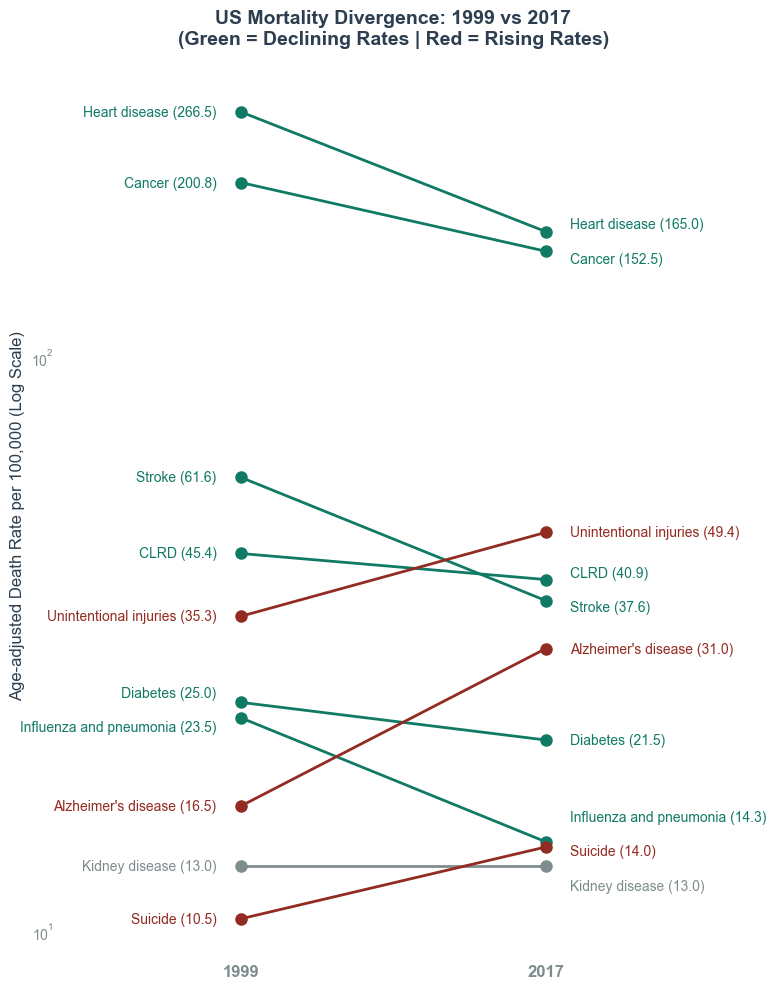

In [3]:
# Filter to United States only for national level analysis
df_us = df[df['State'] == 'United States']
df_us_ind = df_us[df_us['Cause Name'] != 'All causes']

# Pivot to get rates by year and cause
piv_us = df_us_ind.pivot(index='Cause Name', columns='Year', values='Age-adjusted Death Rate')
piv_99_17 = piv_us[[1999, 2017]].copy().sort_values(1999, ascending=False)

# Create slope chart
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_yscale('log') # Log scale helps display rates spanning multiple orders of magnitude

# Plot lines
for cause, row in piv_99_17.iterrows():
    val99 = row[1999]
    val17 = row[2017]
    # Color based on trend direction
    color = '#117a65' if val17 < val99 else ('#922b21' if val17 > val99 else '#7f8c8d')
    ax.plot([0, 1], [val99, val17], marker='o', color=color, linewidth=2, markersize=8)

# Format axes
ax.set_xlim(-0.6, 1.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['1999', '2017'], fontsize=12, fontweight='bold')
ax.set_ylabel('Age-adjusted Death Rate per 100,000 (Log Scale)', fontsize=12)

# Remove spines
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)
ax.grid(visible=False)

# Adjust label vertical spacing in log space to prevent overlaps
log_y_99 = [(np.log10(row[1999]), cause) for cause, row in piv_99_17.iterrows()]
log_y_17 = [(np.log10(row[2017]), cause) for cause, row in piv_99_17.iterrows()]

def adjust_log_labels(log_y, min_log_dist=0.06):
    log_y = sorted(log_y, key=lambda x: x[0])
    n = len(log_y)
    for _ in range(5): # Iterative adjustment
        for i in range(1, n):
            if log_y[i][0] - log_y[i-1][0] < min_log_dist:
                overlap = min_log_dist - (log_y[i][0] - log_y[i-1][0])
                log_y[i] = (log_y[i][0] + overlap/2, log_y[i][1])
                log_y[i-1] = (log_y[i-1][0] - overlap/2, log_y[i-1][1])
        for i in range(n-2, -1, -1):
            if log_y[i+1][0] - log_y[i][0] < min_log_dist:
                overlap = min_log_dist - (log_y[i+1][0] - log_y[i][0])
                log_y[i] = (log_y[i][0] - overlap/2, log_y[i][1])
                log_y[i+1] = (log_y[i+1][0] + overlap/2, log_y[i+1][1])
    return {cause: 10**y for y, cause in log_y}

adj_y_99 = adjust_log_labels(log_y_99)
adj_y_17 = adjust_log_labels(log_y_17)

# Draw labels
for cause, row in piv_99_17.iterrows():
    val99 = row[1999]
    val17 = row[2017]
    color = '#117a65' if val17 < val99 else ('#922b21' if val17 > val99 else '#7f8c8d')
    
    # Left label
    y_pos_99 = adj_y_99[cause]
    ax.text(-0.08, y_pos_99, f"{cause} ({val99:.1f})", ha='right', va='center', fontsize=10, color=color)
    
    # Right label
    y_pos_17 = adj_y_17[cause]
    ax.text(1.08, y_pos_17, f"{cause} ({val17:.1f})", ha='left', va='center', fontsize=10, color=color)

plt.title("US Mortality Divergence: 1999 vs 2017\n(Green = Declining Rates | Red = Rising Rates)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Chapter 2: The Great Shuffling: Relative Health Rankings

**What are we looking at?**
We are looking at how health rankings for US states changed over time. We track ten specific states that show different paths.

**Why does it matter?**
A state can improve its death rate but still fall behind other states. Looking at rankings shows us who is leading and who is falling behind in the race for better health.

**What did we learn?**
We learned that Hawaii is always the healthiest state. Mississippi and West Virginia are always near the bottom. More surprisingly, coastal regions like New York, New Jersey, and Washington D.C. climbed very fast. Historically healthy plains states like Iowa, South Dakota, and Idaho slipped ten to twenty spots.

**What should we look at next?**
What caused these opposite paths? We need to look at the specific causes of death to explain why Washington D.C. jumped twenty-seven ranks while West Virginia fell to the very bottom.

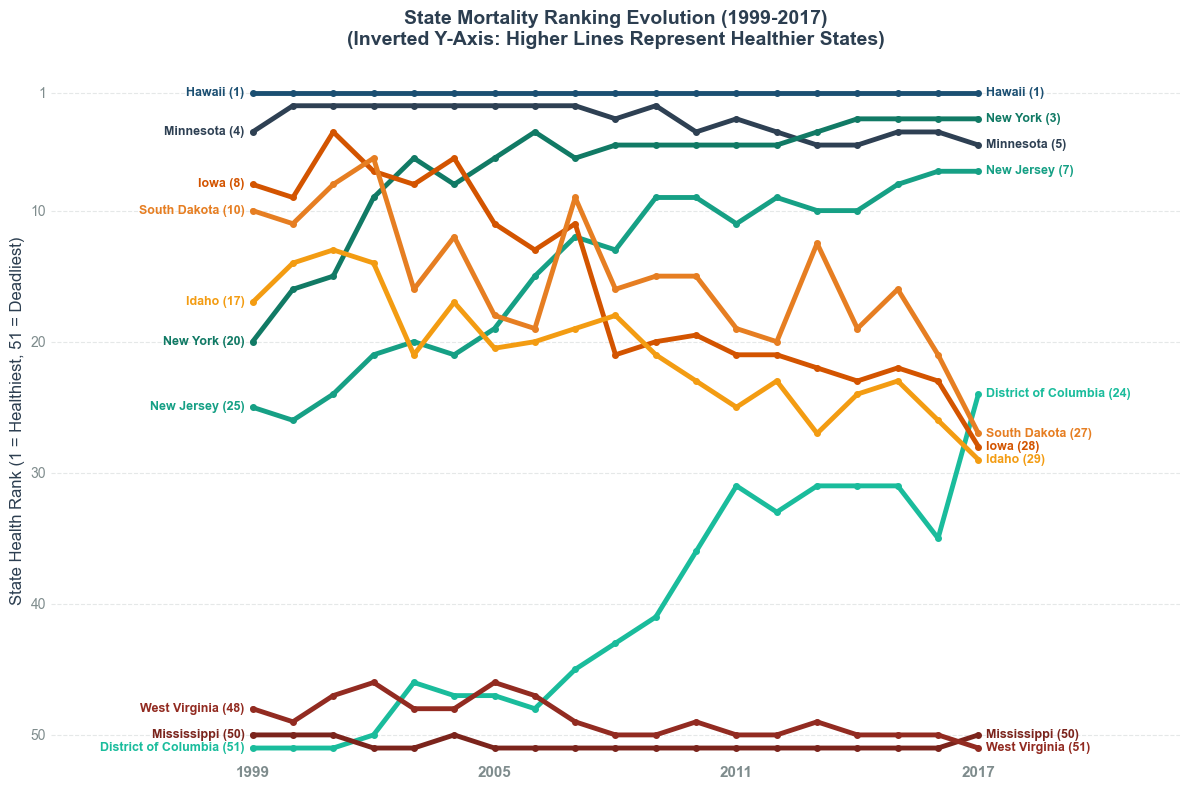

In [4]:
# Filter out the United States aggregate to focus on states and D.C.
df_states = df[df['State'] != 'United States']

# Pivot and rank (1 = healthiest/lowest rate, 51 = deadliest/highest rate)
all_causes = df_states[df_states['Cause Name'] == 'All causes'].pivot(index='Year', columns='State', values='Age-adjusted Death Rate')
ranks = all_causes.rank(axis=1, ascending=True)

# Select states that represent distinct health trajectories
selected_states = {
    'Hawaii': {'color': '#1b4f72', 'label': 'Hawaii (#1 Constant)'},
    'Minnesota': {'color': '#2e4053', 'label': 'Minnesota (Healthy Leader)'},
    'New York': {'color': '#117a65', 'label': 'New York (Riser)'},
    'New Jersey': {'color': '#16a085', 'label': 'New Jersey (Riser)'},
    'District of Columbia': {'color': '#1abc9c', 'label': 'District of Columbia (Superstar Riser)'},
    'Iowa': {'color': '#d35400', 'label': 'Iowa (Quiet Faller)'},
    'South Dakota': {'color': '#e67e22', 'label': 'South Dakota (Quiet Faller)'},
    'Idaho': {'color': '#f39c12', 'label': 'Idaho (Quiet Faller)'},
    'Mississippi': {'color': '#7b241c', 'label': 'Mississippi (Persistent Laggard)'},
    'West Virginia': {'color': '#922b21', 'label': 'West Virginia (Persistent Laggard)'}
}

fig, ax = plt.subplots(figsize=(12, 8))

# Invert y-axis so rank 1 is at the top
ax.set_ylim(52, 0)
ax.set_yticks([1, 10, 20, 30, 40, 50])

# Plot each state
years = list(ranks.index)
for state, config in selected_states.items():
    ax.plot(years, ranks[state], label=config['label'], color=config['color'], linewidth=3.5, marker='o', markersize=4)
    
    # Label at start (1999)
    ax.text(1998.8, ranks.loc[1999, state], f"{state} ({int(ranks.loc[1999, state])})", 
            ha='right', va='center', color=config['color'], fontsize=9, fontweight='bold')
    
    # Label at end (2017)
    ax.text(2017.2, ranks.loc[2017, state], f"{state} ({int(ranks.loc[2017, state])})", 
            ha='left', va='center', color=config['color'], fontsize=9, fontweight='bold')

ax.set_xlim(1994, 2022)
ax.set_xticks([1999, 2005, 2011, 2017])
ax.set_xticklabels(['1999', '2005', '2011', '2017'], fontsize=11, fontweight='bold')
ax.set_ylabel('State Health Rank (1 = Healthiest, 51 = Deadliest)', fontsize=12)

# Remove spines
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)
ax.grid(visible=True, axis='y', color='#e5e8e8', linestyle='--', linewidth=0.8)
ax.grid(visible=False, axis='x')

plt.title("State Mortality Ranking Evolution (1999-2017)\n(Inverted Y-Axis: Higher Lines Represent Healthier States)", fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()

### Chapter 3: Decomposing the Divergence

**What are we looking at?**
We are looking at which causes of death drove the overall changes in six key states.

**Why does it matter?**
We want to see why some states made fast progress while others stopped improving. This analysis shows us which diseases helped a state improve and which ones held it back.

**What did we learn?**
We learned that West Virginia made the biggest improvements in heart disease deaths. But this success was completely wiped out by huge increases in accidental deaths, Alzheimer's, suicide, and lung disease. Washington D.C. made broad improvements across heart disease, cancer, and diabetes. These improvements easily covered its smaller increases in other areas.

**What should we look at next?**
Accidents and suicides played a huge role in holding back states like West Virginia and South Dakota. Where else did these two crises strike most severely?

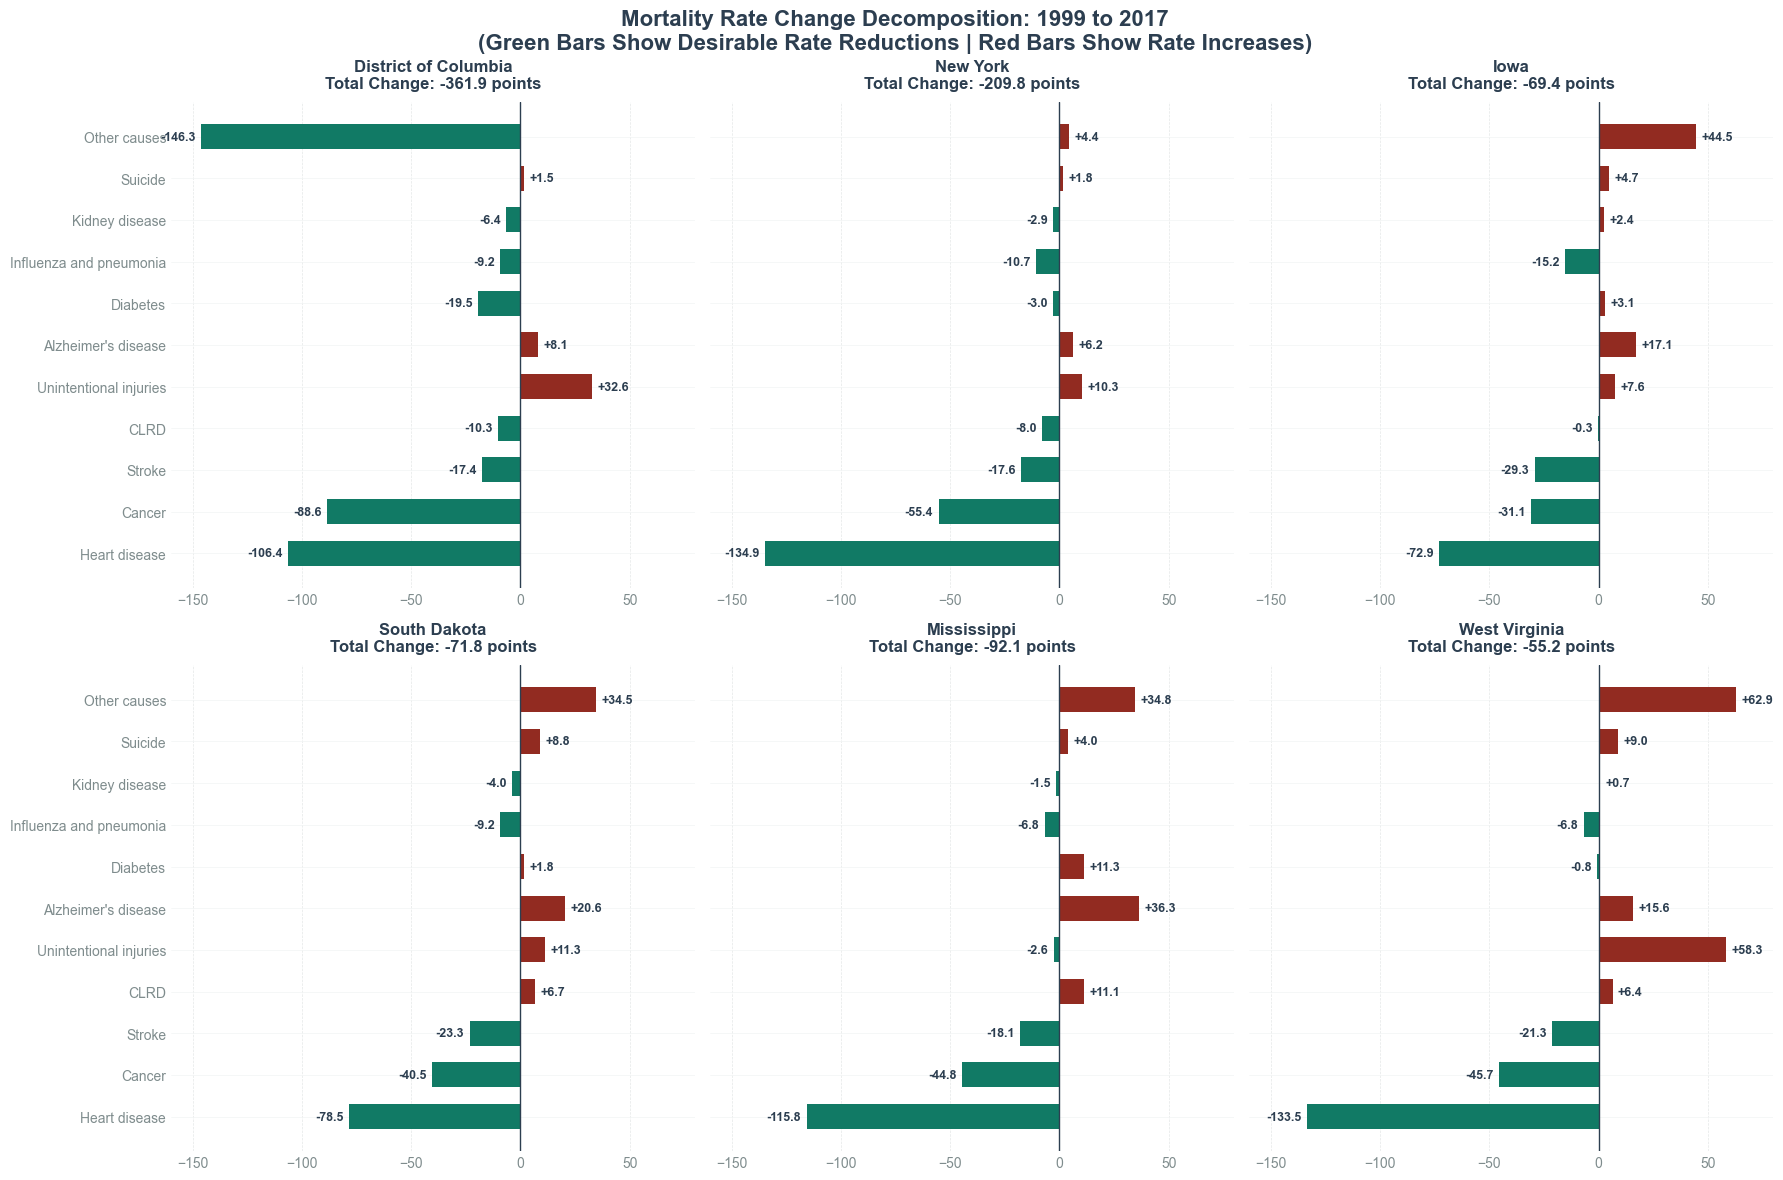

In [5]:
regions = ['District of Columbia', 'New York', 'Iowa', 'South Dakota', 'Mississippi', 'West Virginia']
cause_order = [
    'Heart disease', 'Cancer', 'Stroke', 'CLRD', 'Unintentional injuries',
    "Alzheimer's disease", 'Diabetes', 'Influenza and pneumonia', 'Kidney disease', 'Suicide', 'Other causes'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    df_reg = df[df['State'] == region]
    pivot_reg = df_reg.pivot(index='Year', columns='Cause Name', values='Age-adjusted Death Rate')
    
    # Calculate changes
    changes = {}
    for cause in pivot_reg.columns:
        if cause != 'All causes':
            changes[cause] = pivot_reg.loc[2017, cause] - pivot_reg.loc[1999, cause]
            
    other_1999 = pivot_reg.loc[1999, 'All causes'] - pivot_reg.loc[1999].drop('All causes').sum()
    other_2017 = pivot_reg.loc[2017, 'All causes'] - pivot_reg.loc[2017].drop('All causes').sum()
    changes['Other causes'] = other_2017 - other_1999
    
    # Map to ordered list
    vals = [changes.get(c, 0.0) for c in cause_order]
    
    # Colors (Green for decline in death rate, Red for increase)
    colors = ['#117a65' if v < 0 else ('#922b21' if v > 0 else '#7f8c8d') for v in vals]
    
    # Plot bars
    bars = ax.barh(cause_order, vals, color=colors, height=0.6)
    ax.axvline(0, color='#2c3e50', linewidth=1, linestyle='-')
    
    # Title & details
    total_change = pivot_reg.loc[2017, 'All causes'] - pivot_reg.loc[1999, 'All causes']
    ax.set_title(f"{region}\nTotal Change: {total_change:+.1f} points", fontsize=12, fontweight='bold', pad=10)
    
    # Label bars with value
    for bar in bars:
        width = bar.get_width()
        x_pos = width + (2.5 if width >= 0 else -2.5)
        ha = 'left' if width >= 0 else 'right'
        # Add labels only for visible changes
        if abs(width) > 0.1:
            ax.text(x_pos, bar.get_y() + bar.get_height()/2, f"{width:+.1f}", 
                    ha=ha, va='center', fontsize=9, color='#2c3e50', fontweight='bold')
        
    ax.set_xlim(-160, 80)
    ax.invert_yaxis()  # Invert y-axis on each subplot so we read from top to bottom
    
    # Clean spines
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(False)
    ax.grid(visible=True, axis='x', color='#e5e8e8', linestyle='--', linewidth=0.5)

plt.suptitle("Mortality Rate Change Decomposition: 1999 to 2017\n(Green Bars Show Desirable Rate Reductions | Red Bars Show Rate Increases)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Chapter 4: The Subplot: The 2011 Coding Shift

**What are we looking at?**
We are looking at a sudden change in US death rates for Kidney Disease and Diabetes around 2011.

**Why does it matter?**
In data science, we must watch for sudden drops or jumps that do not make biological sense. In 2011, kidney disease deaths fell in forty-eight states at the exact same time. We must know if this was a real cure or just a change in how records were kept.

**What did we learn?**
We learned that the government changed its data coding rules in 2011. They started listing deaths from kidney disease under diabetes if the patient had both conditions. This shows that record-keeping rules can create an illusion of progress or crisis in public health data.

**What should we look at next?**
Now that we understand this data anomaly, let's look back at the real health crises. Where did accidental deaths and suicides rise the fastest?

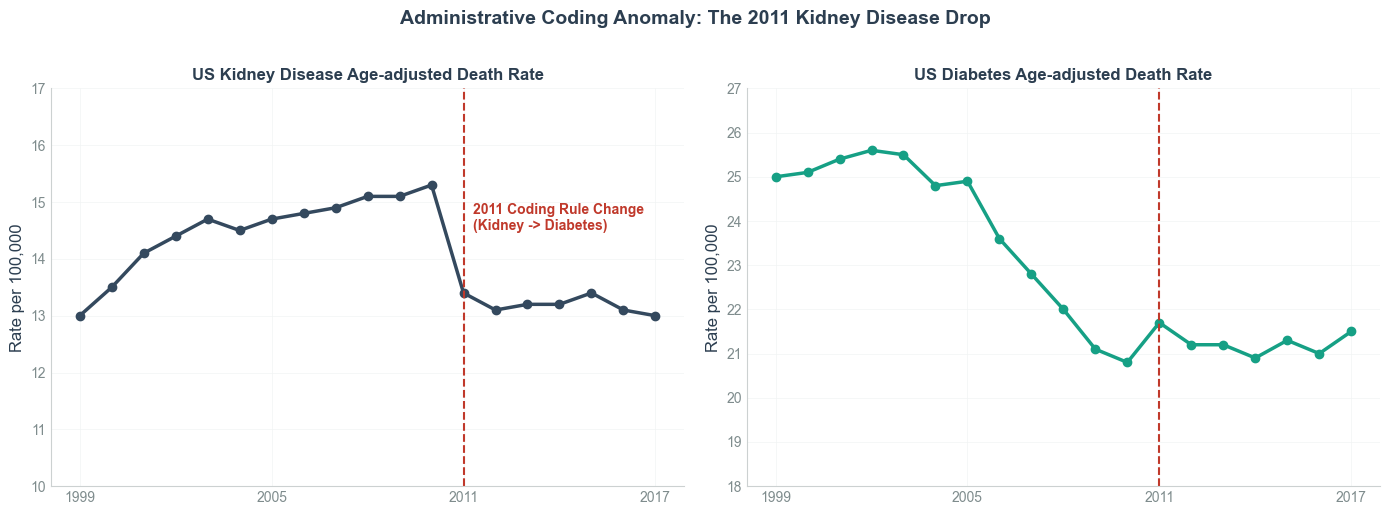

In [6]:
# US Kidney vs Diabetes rates over time
us_kidney = df_us[df_us['Cause Name'] == 'Kidney disease'].set_index('Year')['Age-adjusted Death Rate']
us_diabetes = df_us[df_us['Cause Name'] == 'Diabetes'].set_index('Year')['Age-adjusted Death Rate']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Kidney Disease plot
ax1.plot(us_kidney.index, us_kidney.values, color='#34495e', linewidth=2.5, marker='o')
ax1.axvline(2011, color='#c0392b', linestyle='--', linewidth=1.5)
ax1.text(2011.3, 14.5, "2011 Coding Rule Change\n(Kidney -> Diabetes)", color='#c0392b', fontsize=10, fontweight='bold')
ax1.set_title("US Kidney Disease Age-adjusted Death Rate", fontsize=12, fontweight='bold')
ax1.set_ylabel('Rate per 100,000')
ax1.set_ylim(10, 17)
ax1.set_xticks([1999, 2005, 2011, 2017])
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# Diabetes plot
ax2.plot(us_diabetes.index, us_diabetes.values, color='#16a085', linewidth=2.5, marker='o')
ax2.axvline(2011, color='#c0392b', linestyle='--', linewidth=1.5)
ax2.set_title("US Diabetes Age-adjusted Death Rate", fontsize=12, fontweight='bold')
ax2.set_ylabel('Rate per 100,000')
ax2.set_ylim(18, 27)
ax2.set_xticks([1999, 2005, 2011, 2017])
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

plt.suptitle("Administrative Coding Anomaly: The 2011 Kidney Disease Drop", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chapter 5: The Geography of Despair

**What are we looking at?**
We are looking at death rates for accidents and suicides in the most affected states. We compare them to the national average.

**Why does it matter?**
Accidents and suicides are the main reasons why death rates are rising for younger and middle-aged Americans. We want to see which states became the centers of these crises and how far they went above the national average.

**What did we learn?**
We learned that suicide rose steadily in almost every state. But the rise in accidental deaths was concentrated in just a few areas. States like West Virginia, Ohio, and Pennsylvania saw accidental deaths soar far above the US average. States like Montana, Alaska, and Wyoming remained the tragic leaders in suicide.

**What should we look at next?**
What is the most important lesson we should remember from these very different health paths?

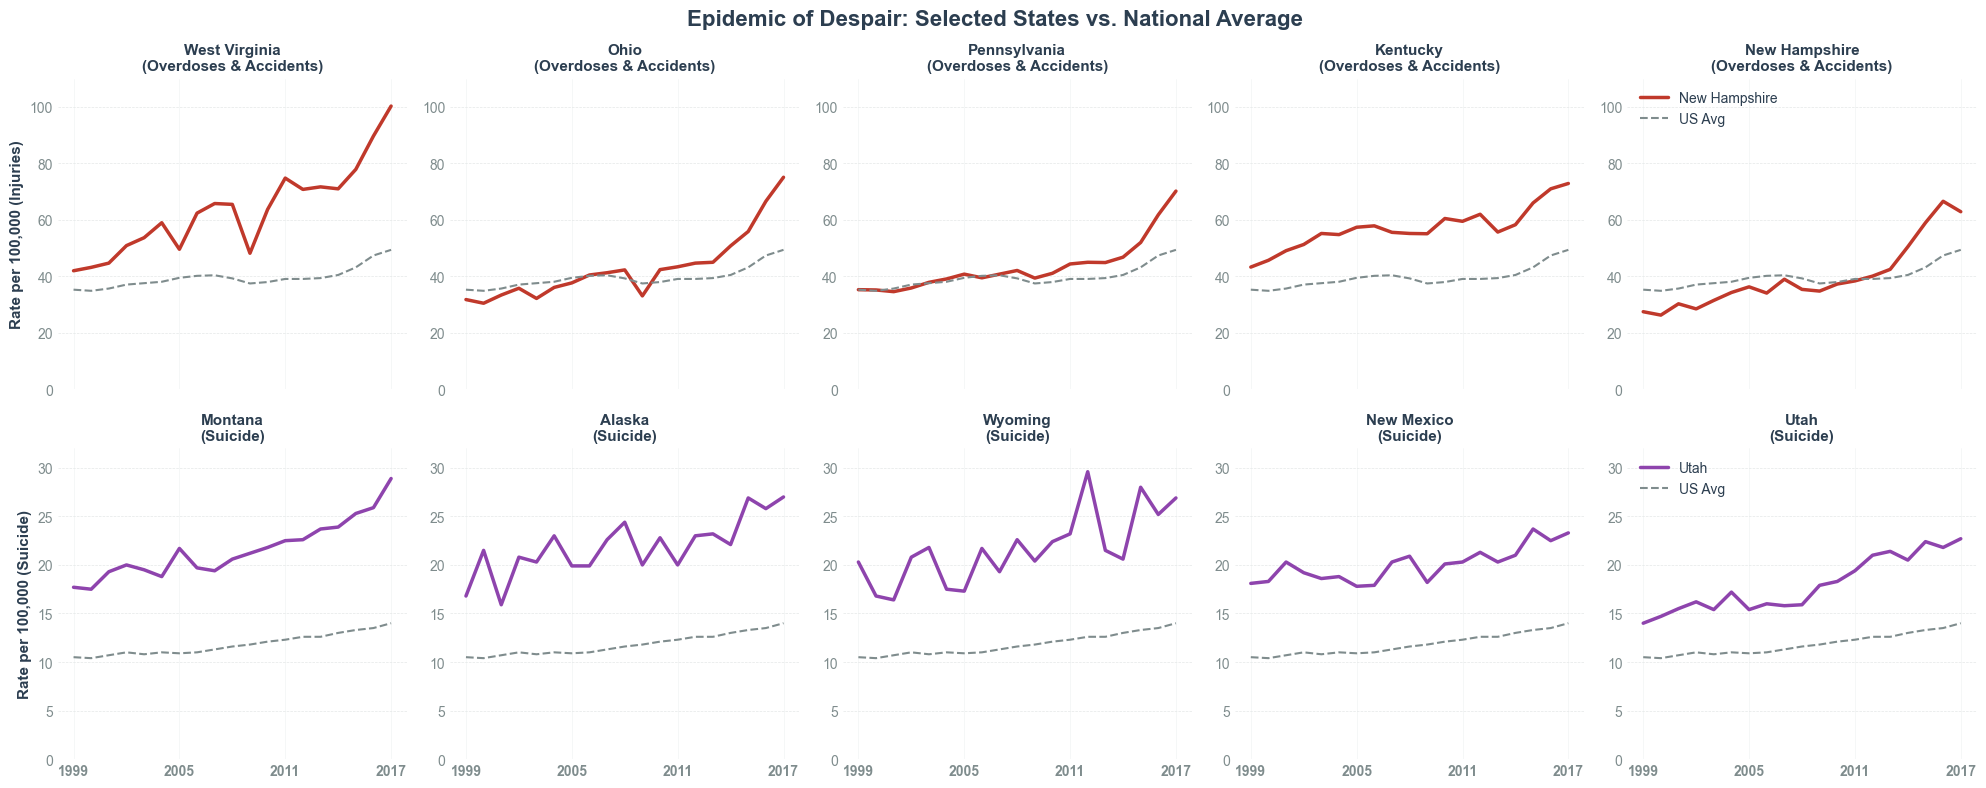

In [7]:
# Hardest hit states
injury_states = ['West Virginia', 'Ohio', 'Pennsylvania', 'Kentucky', 'New Hampshire']
suicide_states = ['Montana', 'Alaska', 'Wyoming', 'New Mexico', 'Utah']

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)

# US trends
us_injury = df_us[df_us['Cause Name'] == 'Unintentional injuries'].set_index('Year')['Age-adjusted Death Rate']
us_suicide = df_us[df_us['Cause Name'] == 'Suicide'].set_index('Year')['Age-adjusted Death Rate']
years = sorted(df['Year'].unique())

# Top Row: Unintentional Injuries (Accidents/Overdoses)
for i, state in enumerate(injury_states):
    ax = axes[0, i]
    state_data = df[(df['State'] == state) & (df['Cause Name'] == 'Unintentional injuries')].set_index('Year')['Age-adjusted Death Rate']
    
    ax.plot(years, state_data, color='#c0392b', linewidth=2.5, label=state)
    ax.plot(years, us_injury, color='#7f8c8d', linewidth=1.5, linestyle='--', label='US Avg')
    
    ax.set_title(f"{state}\n(Overdoses & Accidents)", fontsize=11, fontweight='bold')
    ax.set_ylim(0, 110)
    
    # Hide spines
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(False)
    ax.grid(visible=True, axis='y', color='#e5e8e8', linestyle='--', linewidth=0.5)
    
    if i == 0:
        ax.set_ylabel('Rate per 100,000 (Injuries)', fontsize=11, fontweight='bold')
    if i == 4:
        ax.legend(frameon=False, loc='upper left')

# Bottom Row: Suicide
for i, state in enumerate(suicide_states):
    ax = axes[1, i]
    state_data = df[(df['State'] == state) & (df['Cause Name'] == 'Suicide')].set_index('Year')['Age-adjusted Death Rate']
    
    ax.plot(years, state_data, color='#8e44ad', linewidth=2.5, label=state)
    ax.plot(years, us_suicide, color='#7f8c8d', linewidth=1.5, linestyle='--', label='US Avg')
    
    ax.set_title(f"{state}\n(Suicide)", fontsize=11, fontweight='bold')
    ax.set_ylim(0, 32)
    
    # Hide spines
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(False)
    ax.grid(visible=True, axis='y', color='#e5e8e8', linestyle='--', linewidth=0.5)
    
    if i == 0:
        ax.set_ylabel('Rate per 100,000 (Suicide)', fontsize=11, fontweight='bold')
    if i == 4:
        ax.legend(frameon=False, loc='upper left')
        
    ax.set_xticks([1999, 2005, 2011, 2017])
    ax.set_xticklabels(['1999', '2005', '2011', '2017'], fontsize=10, fontweight='bold')

plt.suptitle("Epidemic of Despair: Selected States vs. National Average", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Chapter 6: Conclusion: The Modern Health Equation

If there is one thing you should remember a week after reading this notebook, it is this: health progress is not automatic or the same for everyone.

The United States made great progress against the main diseases of the twentieth century, like heart disease and cancer. But this progress is threatened by a rise in social and mental health crises. The states that did well over these two decades kept their progress against chronic diseases, but they also kept suicides, accidental drug overdoses, and Alzheimer's rates low.

As we look to the future, the challenge has changed. The battle is no longer just against biology. It is now a battle against despair and the challenges of aging.